# Analisi Semantica e Clustering di Sottografi Anomali
Progetto: Big Data & Machine Learning - Identificazione Best Practice
Obiettivo: Distinguere varianti di processo (Best Practice) da errori operativi.

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import umap
import hdbscan
import re

c:\Users\Enzo\Documents\UNIVPM\1°Anno\BigData\Progetto\myEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ==========================================
# BLOCCO 1: Estrazione Frequenze dal CSV
# ==========================================

csv_file = '../../datasets/fineExp_table2_on_file.csv' 

# Caricamento del dataset
df = pd.read_csv(csv_file, sep=';')

# Escludiamo la colonna 'grafo' per sommare solo le occorrenze dei sottografi
subgraphs_only = df.drop(columns=['grafo'])

# Sommiamo e filtriamo solo quelli con almeno 1 occorrenza
occurrences = subgraphs_only.sum()
occurrences = occurrences[occurrences > 0]

# Creiamo il dizionario ufficiale delle frequenze
freq_dict = occurrences.to_dict()

print(f"Numero di sottografi anomali trovati nel CSV: {len(freq_dict)}")
print(f"Lista degli ID estratti dal CSV:\n{list(freq_dict.keys())}")

✅ Frequenze estratte con successo!
Numero di sottografi anomali trovati nel CSV: 32
Lista degli ID estratti dal CSV:
['Sub5', 'Sub7', 'Sub14', 'Sub19', 'Sub24', 'Sub28', 'Sub30', 'Sub33', 'Sub50', 'Sub54', 'Sub56', 'Sub58', 'Sub59', 'Sub62', 'Sub63', 'Sub64', 'Sub71', 'Sub80', 'Sub81', 'Sub84', 'Sub85', 'Sub88', 'Sub100', 'Sub103', 'Sub113', 'Sub114', 'Sub145', 'Sub174', 'Sub176', 'Sub178', 'Sub179', 'Sub180']


In [ ]:
# ==========================================
# BLOCCO 2: Parsing file di testo e Creazione Grafi
# ==========================================

# Funzione per il parsing del formato 'S v 1 Label d 1 2' in oggetti NetworkX
def parse_subelements(file_content, custom_ids=None):
    """Parsa il formato 'S v 1 Label d 1 2' in oggetti NetworkX."""
    graphs = {}
    blocks = re.split(r'\nS\n|^S\n', file_content.strip())
    valid_blocks = [b for b in blocks if b.strip()]
    
    for i, block in enumerate(valid_blocks):
        G = nx.DiGraph()
        lines = block.strip().split('\n')
        
        # Assegnazione ID: usa custom_ids se forniti, altrimenti usa CorrSub_X
        if custom_ids and i < len(custom_ids):
            sub_id = custom_ids[i]
        else:
            sub_id = f"CorrSub_{i+1}"
            
        for line in lines:
            parts = line.split()
            if len(parts) < 3: continue
            
            # Controllo sul primo elemento della riga
            if parts[0] == 'v':
                G.add_node(int(parts[1]), label=parts[2])
            elif parts[0] in ['d', 'e']:
                G.add_edge(int(parts[1]), int(parts[2]))
                
        graphs[sub_id] = G
    return graphs

# 1. Estraiamo i 27 ID anomali del file (escludendo i 5 finali che aggiungeremo a mano)
tutti_id = list(freq_dict.keys())
anomalous_ids_ordered = tutti_id[:27] 

# 2. Carichiamo i 27 anomali dal file di testo
txt_data = open('../../datasets/custom/anomalous_sub.txt', 'r').read()
subgraphs = parse_subelements(txt_data, custom_ids=anomalous_ids_ordered)

# 3. Funzione per l'aggiunta manuale dei 5 restanti
def add_manual_sub(sub_dict, sub_id, nodes_dict, edges_list):
    G = nx.DiGraph()
    for nid, lbl in nodes_dict.items():
        G.add_node(nid, label=lbl)
    G.add_edges_from(edges_list)
    sub_dict[sub_id] = G

# Aggiungiamo i 5 grafi mancanti per arrivare a 32
add_manual_sub(subgraphs, "Sub174", {1: "AddPenalty", 2: "NotifyOffenders", 3: "ReceiveResults"}, [(1,2), (2,3)])
add_manual_sub(subgraphs, "Sub179", {1: "AddPenalty", 2: "NotifyOffenders", 3: "ReceiveResults"}, [(1,2), (2,3)])
add_manual_sub(subgraphs, "Sub176", {1: "AddPenalty", 2: "AppealToPrefecture", 3: "AppealToJudge", 4: "SendAppeal"}, [(1,2), (2,3), (3,4)])
add_manual_sub(subgraphs, "Sub178", {1: "AddPenalty", 2: "SendAppeal"}, [(1,2)])
add_manual_sub(subgraphs, "Sub180", {1: "SendAppeal", 2: "AppealToJudge", 3: "AddPenalty"}, [(1,2), (2,3)])

# 4. Carichiamo i sottografi corretti (Vocabolario Normativo)
correct_txt_data = open('../../datasets/custom/correct_sub.txt', 'r').read()
correct_subgraphs = parse_subelements(correct_txt_data)

print(f"Sottografi anomali in memoria: {len(subgraphs)} (Devono essere esattamente 32)")
print(f"Sottografi normativi in memoria: {len(correct_subgraphs)}")

✅ Parsing e costruzione grafi completati!
Sottografi anomali in memoria (da 'subgraphs'): 32 (Devono essere esattamente 32)
Sottografi normativi in memoria (da 'correct_subgraphs'): 140


In [ ]:
# ==========================================
# BLOCCO 3: Estrazione Feature (GED e SBERT)
# ==========================================
print("Caricamento del modello SBERT...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

def get_graph_text(G):
    """Estrae una 'frase' dal grafo seguendo l'ordinamento topologico delle attività"""
    try:
        # Se è un DAG, usiamo l'ordinamento topologico (causale)
        sorted_nodes = list(nx.topological_sort(G))
    except nx.NetworkXUnfeasible:
        # Se ci sono dei cicli (loop), facciamo un fallback sui nodi ordinati per ID
        sorted_nodes = sorted(G.nodes())
        
    return " ".join([G.nodes[n].get('label', '') for n in sorted_nodes])

# Funzione per matchare i nodi durante il calcolo della GED
def node_match(n1, n2):
    return n1.get('label') == n2.get('label')

features_dict = {}
target_subs = list(subgraphs.keys()) # I nostri 32 ID

print(f"\nInizio calcolo feature per {len(target_subs)} sottografi anomali...")

for anom_id in target_subs:
    G_anom = subgraphs[anom_id]
    
    min_ged = float('inf')
    best_match_id = None
    best_match_G = None
    
    # 1. Trova il sottografo corretto più simile strutturalmente (GED minima)
    for corr_id, G_corr in correct_subgraphs.items():
        dist = nx.graph_edit_distance(G_anom, G_corr, node_match=node_match)
        
        if dist < min_ged:
            min_ged = dist
            best_match_id = corr_id
            best_match_G = G_corr
            
    # 2. Calcola la similarità semantica con il best match
    text_anom = get_graph_text(G_anom)
    text_corr = get_graph_text(best_match_G)
    
    embedding_anom = sbert_model.encode([text_anom])
    embedding_corr = sbert_model.encode([text_corr])
    sim_score = cosine_similarity(embedding_anom, embedding_corr)[0][0]
    
    # 3. Salviamo le feature (aggiungendo anche la frequenza grezza dal dizionario precedente)
    features_dict[anom_id] = {
        'ged': min_ged,
        'semantic_sim': sim_score,
        'freq': freq_dict[anom_id],
        'matched_with': best_match_id,
        'text_anom': text_anom, 
        'text_corr': text_corr
    }
    
    print(f"{anom_id} completato -> GED: {min_ged:.1f} | Sim: {sim_score:.3f} | Freq: {freq_dict[anom_id]}")


Caricamento del modello SBERT...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2981.91it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Inizio calcolo feature per 32 sottografi anomali...
Sub5 completato -> GED: 2.0 | Sim: 0.860 | Freq: 120
Sub7 completato -> GED: 2.0 | Sim: 0.997 | Freq: 39
Sub14 completato -> GED: 2.0 | Sim: 0.982 | Freq: 25
Sub19 completato -> GED: 1.0 | Sim: 0.942 | Freq: 2772
Sub24 completato -> GED: 3.0 | Sim: 0.652 | Freq: 15
Sub28 completato -> GED: 2.0 | Sim: 0.395 | Freq: 296
Sub30 completato -> GED: 2.0 | Sim: 0.852 | Freq: 7
Sub33 completato -> GED: 1.0 | Sim: 0.896 | Freq: 9
Sub50 completato -> GED: 1.0 | Sim: 0.907 | Freq: 3
Sub54 completato -> GED: 1.0 | Sim: 0.802 | Freq: 6
Sub56 completato -> GED: 1.0 | Sim: 0.521 | Freq: 34
Sub58 completato -> GED: 1.0 | Sim: 0.837 | Freq: 283
Sub59 completato -> GED: 1.0 | Sim: 0.933 | Freq: 6
Sub62 completato -> GED: 2.0 | Sim: 0.929 | Freq: 28
Sub63 completato -> GED: 2.0 | Sim: 0.982 | Freq: 2
Sub64 completato -> GED: 1.0 | Sim: 0.877 | Freq: 4
Sub71 completato -> GED: 1.0 | Sim: 0.409 | Freq: 13
Sub80 completato -> GED: 1.0 | Sim: 0.957 | Freq: 

In [39]:
# ==========================================
# BLOCCO 4: Costruzione Matrice e Scaling
# ==========================================

# 1. Creiamo il DataFrame dal nostro dizionario delle feature
df_features = pd.DataFrame.from_dict(features_dict, orient='index')

# Manteniamo una copia dei testi e del match per analisi finale
df_info = df_features[['matched_with', 'text_anom', 'text_corr', 'freq']].copy()

# 2. Isoliamo le feature numeriche
df_cluster = df_features[['ged', 'semantic_sim', 'freq']].copy()

# 3. Applichiamo la Frequenza Logaritmica
# Usiamo log1p (che fa log(1 + x)) così la frequenza 0 non potrebbe dare errore,
# e la frequenza 1 diventa un numero gestibile.
df_cluster['log_freq'] = np.log1p(df_cluster['freq'])

# Scartiamo la frequenza grezza, ora usiamo solo quella logaritmica
df_cluster = df_cluster.drop(columns=['freq'])

# 4. Standardizzazione delle feature (fondamentale per UMAP/HDBSCAN)
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(df_cluster)

# Creiamo un DataFrame con i dati scalati per comodità visiva
df_scaled = pd.DataFrame(
    scaled_matrix, 
    columns=['ged_scaled', 'sim_scaled', 'log_freq_scaled'], 
    index=df_cluster.index
)

print("Matrice delle feature creata e scalata con successo!\n")
print("Prime 5 righe del DataFrame scalato pronto per il clustering:")
df_scaled.head()

Matrice delle feature creata e scalata con successo!

Prime 5 righe del DataFrame scalato pronto per il clustering:


,ged_scaled,sim_scaled,log_freq_scaled
Sub5,0.620456,0.224709,1.173895
Sub7,0.620456,1.059929,0.604530
Sub14,0.620456,0.970052,0.382947
Sub19,-0.906821,0.724542,2.784858
Sub24,2.147733,-1.050370,0.133214


c:\Users\Enzo\Documents\UNIVPM\1°Anno\BigData\Progetto\myEnv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clustering completato!
Numero di Cluster regolari trovati: 4
Sottografi classificati come Rumore/Errori: 7


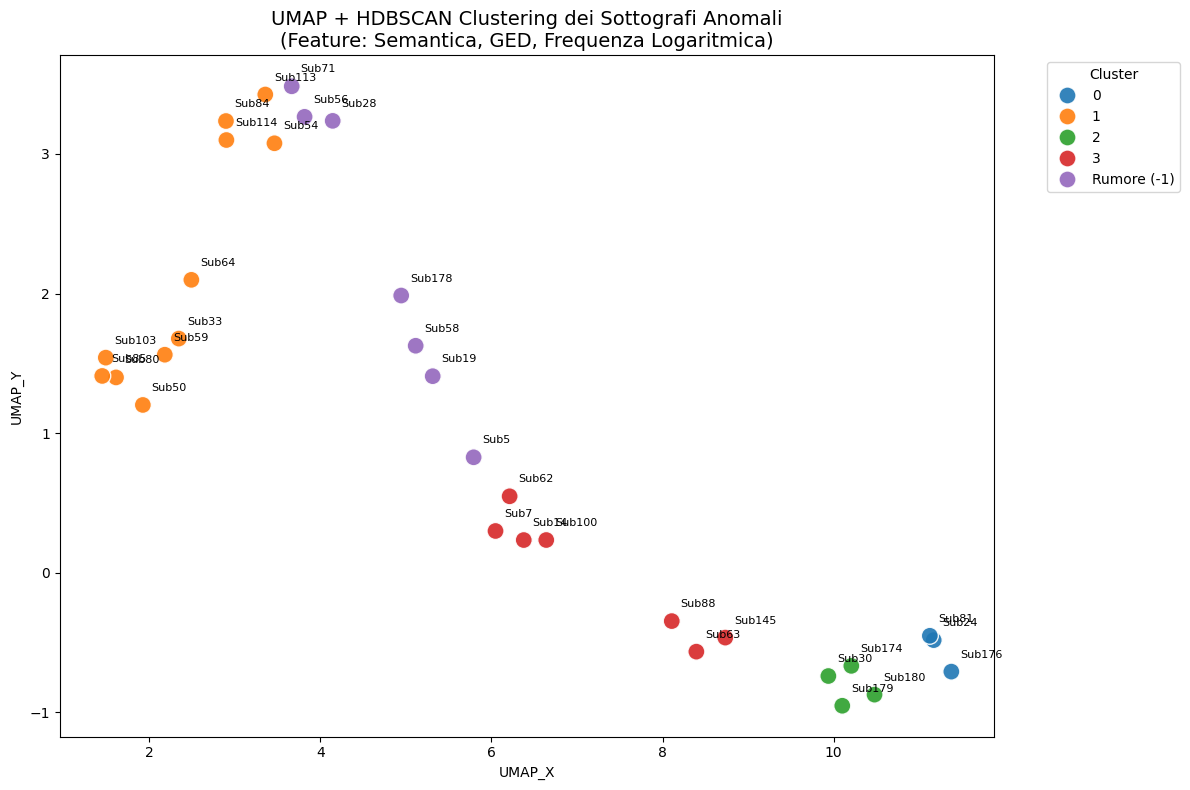


--- Dettaglio Classificazione ---
        ged  semantic_sim  freq      Cluster
Sub176  3.0      0.674086     1            0
Sub24   3.0      0.651534    15            0
Sub81   3.0      0.772870     3            0
Sub64   1.0      0.877191     4            1
Sub114  1.0      0.819868     2            1
Sub113  1.0      0.759423     5            1
Sub33   1.0      0.896222     9            1
Sub50   1.0      0.907209     3            1
Sub54   1.0      0.802094     6            1
Sub103  1.0      0.970013     2            1
Sub85   1.0      0.977584     2            1
Sub59   1.0      0.933486     6            1
Sub84   1.0      0.808120     2            1
Sub80   1.0      0.957204     3            1
Sub179  2.0      0.792267     1            2
Sub174  2.0      0.792267     1            2
Sub180  2.0      0.762674     1            2
Sub30   2.0      0.851578     7            2
Sub63   2.0      0.982428     2            3
Sub62   2.0      0.928938    28            3
Sub88   2.0      0.9

In [76]:
# ==========================================
# BLOCCO 5: Clustering con HDBSCAN e UMAP 
# ==========================================

# 1. Eseguiamo HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=2, metric='euclidean')
labels = clusterer.fit_predict(scaled_matrix)

# Forziamo i label a essere Stringhe (Testo) per risolvere il bug visivo di Seaborn
df_features['Cluster'] = [str(lbl) if lbl != -1 else "Rumore (-1)" for lbl in labels]

# 2. Riduciamo a 2D tramite UMAP
reducer = umap.UMAP(n_neighbors=5, min_dist=0.001, random_state=42)
embedding = reducer.fit_transform(scaled_matrix)

df_features['UMAP_X'] = embedding[:, 0]
df_features['UMAP_Y'] = embedding[:, 1]

# 3. Stampiamo i risultati ripuliti
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Clustering completato!")
print(f"Numero di Cluster regolari trovati: {n_clusters}")
print(f"Sottografi classificati come Rumore/Errori: {n_noise}")

# 4. Generiamo il grafico a dispersione con Palette Dinamica
plt.figure(figsize=(12, 8))

unique_clusters = sorted(df_features['Cluster'].unique())

sns.scatterplot(
    data=df_features, 
    x='UMAP_X', 
    y='UMAP_Y', 
    hue='Cluster',
    hue_order=unique_clusters,
    s=150, 
    alpha=0.9
)

# Annotiamo i grafi chiave
grafi_chiave = target_subs  # Tutti i 32 sottografi anomali
for idx in grafi_chiave:
    if idx in df_features.index:
        plt.annotate(
            idx, 
            (df_features.loc[idx, 'UMAP_X'] + 0.1, df_features.loc[idx, 'UMAP_Y'] + 0.1), 
            fontsize=8
        )

plt.title('UMAP + HDBSCAN Clustering dei Sottografi Anomali\n(Feature: Semantica, GED, Frequenza Logaritmica)', fontsize=14)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Dettaglio finale
print("\n--- Dettaglio Classificazione ---")
print(df_features[['ged', 'semantic_sim', 'freq', 'Cluster']].sort_values('Cluster'))


c:\Users\Enzo\Documents\UNIVPM\1°Anno\BigData\Progetto\myEnv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


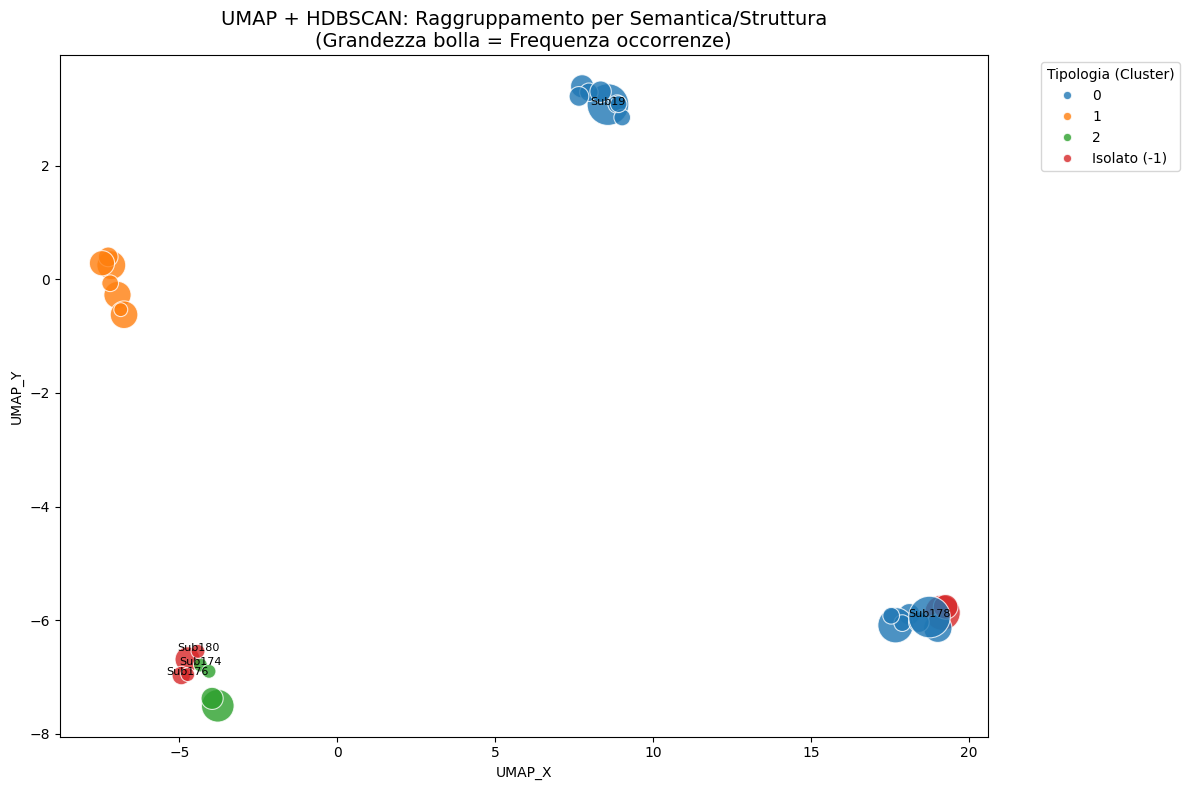


--- Analisi Logica Finale ---
        ged  semantic_sim  freq       Cluster
Sub64   1.0      0.877191     4             0
Sub85   1.0      0.977584     2             0
Sub84   1.0      0.808120     2             0
Sub113  1.0      0.759423     5             0
Sub80   1.0      0.957204     3             0
Sub114  1.0      0.819868     2             0
Sub178  1.0      0.554525  2732             0
Sub59   1.0      0.933486     6             0
Sub56   1.0      0.521113    34             0
Sub58   1.0      0.836987   283             0
Sub50   1.0      0.907209     3             0
Sub33   1.0      0.896222     9             0
Sub19   1.0      0.942034  2772             0
Sub54   1.0      0.802094     6             0
Sub103  1.0      0.970013     2             0
Sub100  2.0      0.997643    15             1
Sub62   2.0      0.928938    28             1
Sub63   2.0      0.982428     2             1
Sub145  2.0      0.941247     1             1
Sub14   2.0      0.982217    25             1
Sub

In [74]:
# ==========================================
# BLOCCO 5-BIS: Clustering su Natura (GED+Sim) e Freq visiva
# ==========================================

# 1. Rifacciamo lo scaling SOLO su GED e Semantica
df_nature = df_features[['ged', 'semantic_sim']].copy()
scaler_nature = StandardScaler()
scaled_nature = scaler_nature.fit_transform(df_nature)

# 2. HDBSCAN sui dati bidimensionali
clusterer_nature = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=3, metric='euclidean')
labels_nature = clusterer_nature.fit_predict(scaled_nature)

df_features['Cluster'] = [str(lbl) if lbl != -1 else "Isolato (-1)" for lbl in labels_nature]

# 3. UMAP sulla matrice bidimensionale
reducer_nature = umap.UMAP(n_neighbors=5, min_dist=0.001, random_state=42)
embedding_nature = reducer_nature.fit_transform(scaled_nature)

df_features['UMAP_X'] = embedding_nature[:, 0]
df_features['UMAP_Y'] = embedding_nature[:, 1]

# 4. GRAFICO: Usiamo df_features['freq'] per la dimensione dei punti 
plt.figure(figsize=(12, 8))

unique_clusters = sorted(df_features['Cluster'].unique())

# Creiamo una colonna per le dimensioni delle bolle (aggiungiamo una base minima per non far sparire i freq=1)
# Usiamo il log_freq calcolato prima per evitare che i freq=2700 coprano l'intero schermo
df_features['bubble_size'] = np.log1p(df_features['freq']) * 100 

sns.scatterplot(
    data=df_features, 
    x='UMAP_X', 
    y='UMAP_Y', 
    hue='Cluster', 
    size='bubble_size', 
    sizes=(100, 900),  # Range di grandezza delle bolle
    hue_order=unique_clusters,
    alpha=0.8
)

# Annotiamo i grafi chiave
for idx in grafi_chiave:
    if idx in df_features.index:
        plt.annotate(
            idx, 
            (df_features.loc[idx, 'UMAP_X'], df_features.loc[idx, 'UMAP_Y']), 
            fontsize=8, 
            ha='center' # Centriamo il testo sulle bolle
        )

plt.title('UMAP + HDBSCAN: Raggruppamento per Semantica/Struttura\n(Grandezza bolla = Frequenza occorrenze)', fontsize=14)
# Rimuoviamo la legenda delle dimensioni che confonde, teniamo solo quella dei colori
handles, labels = plt.gca().get_legend_handles_labels()
# Filtra la legenda per mostrare solo i cluster
cluster_handles = [h for h, l in zip(handles, labels) if l in unique_clusters]
plt.legend(cluster_handles, unique_clusters, title='Tipologia (Cluster)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Stampa finale
print("\n--- Analisi Logica Finale ---")
print(df_features[['ged', 'semantic_sim', 'freq', 'Cluster']].sort_values('Cluster'))

# Conclusioni dell'Analisi di Process Mining: Subgraph Clustering

## 1. Obiettivo Raggiunto
L'applicazione combinata di metriche strutturali (Graph Edit Distance - GED), metriche semantiche (Sentence-BERT) e algoritmi di densità topologica (UMAP + HDBSCAN) ha permesso di superare i limiti dell'analisi di conformità binaria (corretto/errato). Il sistema è ora in grado di isolare e classificare i Local Instance Graphs (LIG) anomali, distinguendo in modo oggettivo gli errori operativi puntuali dalle *Best Practice* non formalizzate.

## 2. Metodologia di Classificazione
Il clustering è stato eseguito isolando la frequenza dal calcolo spaziale per evitare distorsioni (l'effetto *outlier* delle varianti molto comuni). 
I cluster (Archetipi) sono stati calcolati esclusivamente sulla "Natura" della deviazione:
* **Distanza Strutturale (GED):** Calcolata contro il "Best Match" normativo (distanza minima rispetto al dizionario delle tracce corrette).
* **Similarità Semantica:** Calcolata tramite SBERT sulle label ordinate topologicamente, per catturare l'intento dell'attività al di là della struttura.

La **Frequenza** è stata utilizzata ex-post come peso statistico (Lente d'Ingrandimento) per validare l'importanza del cluster.

## 3. Risultati Emergenti (Archetipi di Deviazione)
L'analisi visiva e numerica ha evidenziato 4 macro-isole strutturali:

* **Archetipo "Variazioni Minori" (es. Sub19):** Caratterizzato da una GED minima (1.0) e un'altissima similarità semantica (> 0.87). Rappresenta alterazioni marginali del flusso. L'enorme frequenza del Sub19 (~2772 occorrenze) all'interno di questo spazio lo convalida formalmente come **Candidato Best Practice** (Variante di Sistema da reintegrare nel modello tramite *Model Repair*).
* **Archetipo "Deviazioni Semantiche" (es. Sub178):** Caratterizzato da alterazioni minime del grafo (GED 1.0) ma accompagnato da un calo della similarità semantica (0.39 - 0.83). Indica l'introduzione di concetti operativi alternativi. Anche in questo caso, la frequenza massiccia del Sub178 (~2732 occorrenze) suggerisce un *workaround* burocratico consolidato.
* **Archetipi degli "Errori Strutturali":** Cluster caratterizzati da GED elevate (≥ 2.0) e frequenze marginali (spesso pari a 1). Contengono i veri e propri **Errori Operativi**, come nodi inesistenti nel modello originale (`NotifyOffenders` nel Sub174 e Sub179) o loop causali illogici.

## 4. Prossimi Passi
I risultati confermano la validità dell'approccio *BIG (Building Instance Graphs)* accoppiato al Machine Learning denso. I candidati *Best Practice* verranno proposti per l'estensione del modello normativo (Model Enhancement), mentre gli errori operativi a bassa frequenza manterranno il loro status di violazione.